In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd
import datetime
from time import sleep

import encosid

SIGNAL_DT_MS = 1. # 1ms
gen = encosid.SignalGenerator("can0", 1)

## Проверка

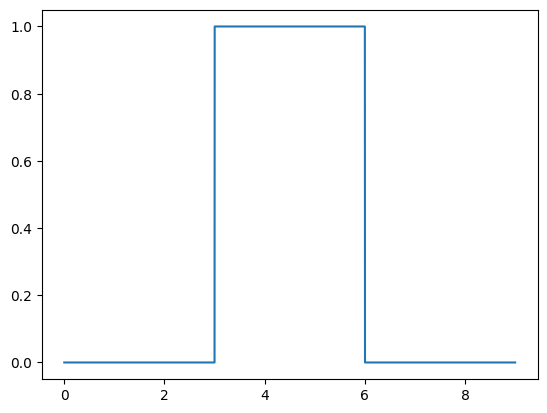

In [17]:
PULSE_LEN_S = 3
AMPLITUDE = 1

T = np.arange(0, 3*PULSE_LEN_S, 1e-3*SIGNAL_DT_MS)
pulse_len = int(PULSE_LEN_S * 1e3 / SIGNAL_DT_MS)

X = np.zeros_like(T)
X[pulse_len:-pulse_len] = AMPLITUDE

plt.plot(T, X)
plt.show()


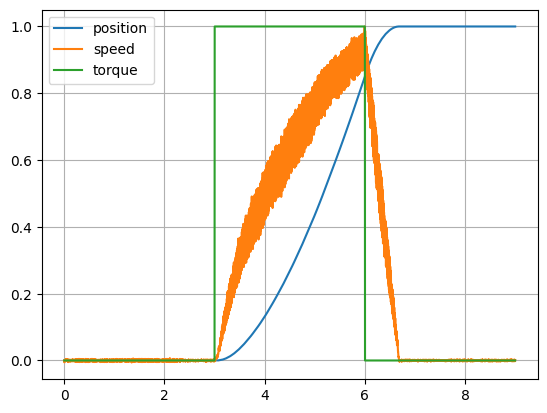

vmax = 8.19536018371582


In [18]:
def stitch(Y, tol=1e-2):
  Y = Y.copy()
  for i in range(len(Y) - 1):
    dy = Y[i + 1] - Y[i]
    shift = dy # TODO include remainder
    if np.abs(dy) >= 2*np.pi - tol:
      Y[i + 1:] -= shift
  return Y

Y, dY = gen.play_signal(X, SIGNAL_DT_MS)
Y = np.array(Y)
Y = stitch(Y - Y[0])
dY = np.array(dY)

plt.plot(T, Y / np.max(Y), label="position")
plt.plot(T, dY / np.max(np.abs(dY)), label="speed")
#plt.plot(T[:-1], (Y[1:] - Y[:-1]) / SIGNAL_DT_MS * 1e3, label="speed, numeric")
plt.plot(T, X / np.max(np.abs(X)), label="torque")
plt.grid()
plt.legend()
plt.show()

print(f"vmax = {np.max(np.abs(dY))}")

## Генерация гармоник

In [19]:
def gen_bins(M, Nmin, Nmax, rng: np.random.Generator):
  nbins = None
  if M == 1:
    nbins = 1
  else:
    nbins = rng.integers(1, M)
  
  bins = set()
  gen = lambda: rng.integers(Nmin, Nmax)
  for _ in range(nbins):
    val = gen()
    while val in bins:
      val = gen()
    bins.add(val)

  return np.array(list(bins))

def gen_random_harmonics(M, N, fmax, seed):
  fnyq = 1e3 / SIGNAL_DT_MS / 2
  F = np.linspace(-fnyq, fnyq, 2*N)

  rng = np.random.default_rng(seed=seed)

  binmax = N * (fmax / fnyq)
  if binmax > N: binmax = N

  bins = gen_bins(M, 0, binmax, rng)

  X = np.zeros((2 * N,), dtype=np.complex64)

  X.real[bins] = rng.random(len(bins))
  X.imag[bins] = rng.random(len(bins))

  X.real[2*N - bins] = X.real[bins]
  X.imag[2*N - bins] = -X.imag[bins]
  return F, X

def gen_signal(X, N):
  x = np.fft.ifft(X)
  T = 1e-3 * np.linspace(0, 2*N * SIGNAL_DT_MS, 2*N)
  return T, np.real(x) / np.max(np.abs(np.real(x)))

def extend_signal(T, x, n):
  new_x = np.ndarray((len(x) + 2*n), dtype=x.dtype)
  new_x[:n] = 0
  new_x[n: len(x) + n] = x.copy()
  new_x[-n:] = 0
  
  N = np.arange(1, n + 1)
  new_t = np.ndarray((len(x) + 2*n), dtype=T.dtype)
  new_t[:n] = -T[-1] * N[::-1] / len(T)
  new_t[n: len(T) + n] = T
  new_t[-n:] = T[-1] * (1 + N / len(T))

  return new_t, new_x


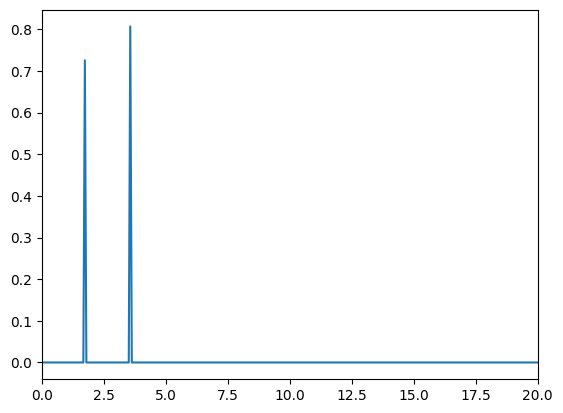

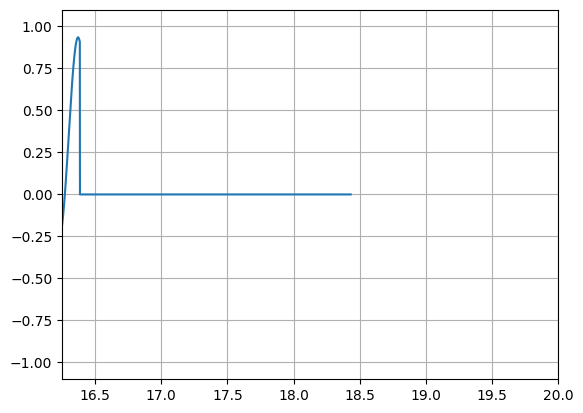

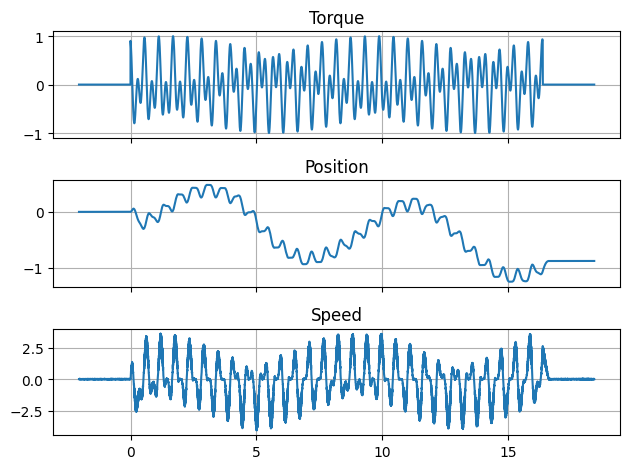

In [22]:
N = 4096*2
F, X = gen_random_harmonics(3, N, 20, 3)
T, x = gen_signal(X, N)
T, x = extend_signal(T, x, 2048)

plt.plot(F[N:], np.abs(X)[:N])
plt.xlim(0, 20)
plt.show()

plt.plot(T, x)
plt.xlim(16.25, 20)
plt.grid()
plt.show()

y, dy = map(np.array, gen.play_signal(3*x, SIGNAL_DT_MS))
y = stitch(y - y[0])

fig, ax = plt.subplots(3, 1, sharex=True)
ax[0].plot(T, x)
ax[0].grid()
ax[0].set_title("Torque")
ax[1].plot(T, y)
ax[1].set_title("Position")
ax[1].grid()
ax[2].plot(T, dy)
ax[2].set_title("Speed")
ax[2].grid()
fig.tight_layout()

## Ээксперимент

In [ ]:
SEEDS = range(10)
NHARMONIC = 5
NFFT = 4096*2
FMAX = 10
ACTION_SCALES = [1, 2, 4, 8, 16]
DATASET = "harmonic_noload"

for seed in SEEDS:
  for scale in ACTION_SCALES:
    F, X = gen_random_harmonics(NHARMONIC, N, FMAX, seed)
    T, x = gen_signal(X, N)
    T, x = extend_signal(T, x, 256)
    x *= scale
    y, dy = map(np.array, gen.play_signal(x, SIGNAL_DT_MS))

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d-%H:%M:%S")
    name = f"seed_{seed}_as_{scale}_{timestamp}.csv"

    df = pd.DataFrame()
    df["time"] = T
    df["torque"] = x
    df["position"] = stitch(y)
    df["speed"] = dy

    df.to_csv(f"datasets/{DATASET}/{name}", index=False)
    sleep(3) # let the drive stop

RuntimeError: read(): Resource temporarily unavailable